In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:

data = pd.read_csv('autompg.csv')
print(data.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  year  \
0  18.0          8         307.0        130    3504          12.0    70   
1  15.0          8         350.0        165    3693          11.5    70   
2  18.0          8         318.0        150    3436          11.0    70   
3  16.0          8         304.0        150    3433          12.0    70   
4  17.0          8         302.0        140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [5]:
print(data.dtypes)


mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object


In [6]:
print("Давхцсан мөр:", data.duplicated().sum())

data = data.drop_duplicates()


Давхцсан мөр: 0


In [8]:

import numpy as np
a=(data=='?').sum()
print ("dutuu utga: ", a)

data['horsepower'] = data['horsepower'].replace('?', np.nan)
data['horsepower'] = data['horsepower'].astype(float)

data['horsepower'] = data['horsepower'].fillna(data['horsepower'].median())
print(data.isnull().sum())

dutuu utga  mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.773453 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.841284  0.896017   
displacement -0.804203   0.950721      1.000000    0.895778  0.932824   
horsepower   -0.773453   0.841284      0.895778    1.000000  0.862442   
weight       -0.831741   0.896017      0.932824    0.862442  1.000000   
acceleration  0.420289  -0.505419     -0.543684   -0.686590 -0.417457   
year          0.579267  -0.348746     -0.370164   -0.413733 -0.306564   
origin        0.563450  -0.562543     -0.609409   -0.452096 -0.581024   

              acceleration      year    origin  
mpg               0.420289  0.579267  0.563450  
cylinders        -0.505419 -0.348746 -0.562543  
displacement     -0.543684 -0.370164 -0.609409  
horsepower       -0.686590 -0.413733 -0.452096  
weight           -0.417457 -0.306564 -0.581024  
acceleration      1.000000  0.288137  0.205873  

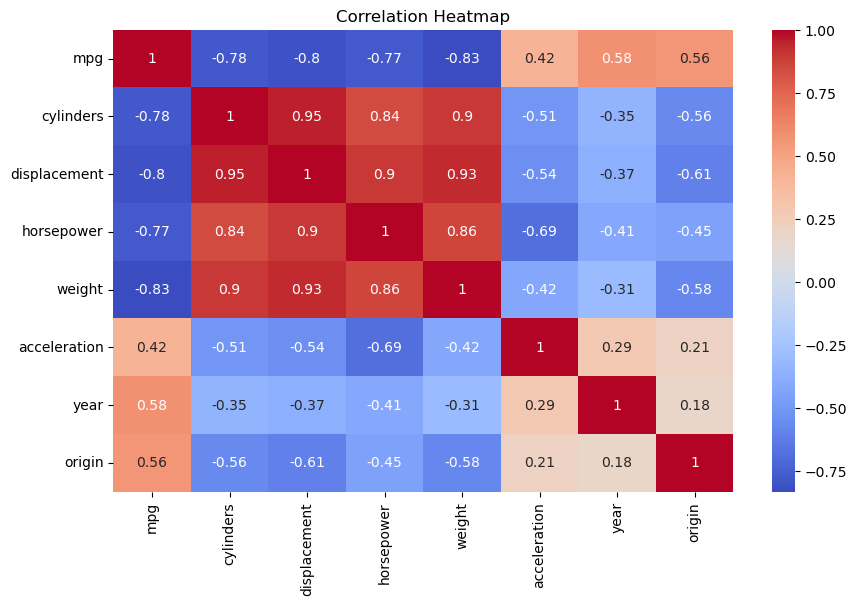

In [11]:
corr = data.corr(numeric_only=True)
print(corr)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
data = data.drop("name", axis=1)

print(data.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0       130.0    3504          12.0    70   
1  15.0          8         350.0       165.0    3693          11.5    70   
2  18.0          8         318.0       150.0    3436          11.0    70   
3  16.0          8         304.0       150.0    3433          12.0    70   
4  17.0          8         302.0       140.0    3449          10.5    70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  


In [13]:
data.insert(len(data.columns), 'weight_kg', (data['weight'] * 0.4535924).astype(int))
print(data.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0       130.0    3504          12.0    70   
1  15.0          8         350.0       165.0    3693          11.5    70   
2  18.0          8         318.0       150.0    3436          11.0    70   
3  16.0          8         304.0       150.0    3433          12.0    70   
4  17.0          8         302.0       140.0    3449          10.5    70   

   origin  weight_kg  
0       1       1589  
1       1       1675  
2       1       1558  
3       1       1557  
4       1       1564  


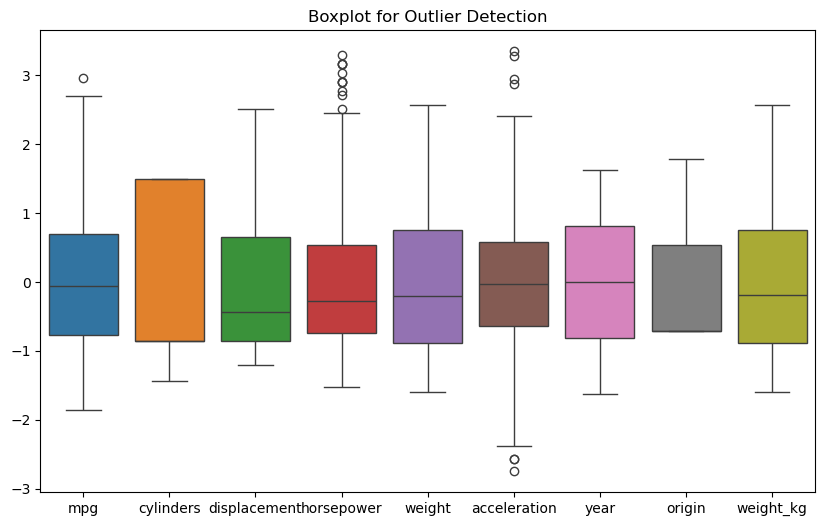

In [16]:
scaler = StandardScaler()

numeric_cols = data.select_dtypes(include=np.number).columns

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [17]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

IQR = Q3 - Q1

data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Outlier removed shape:", data.shape)
pca = PCA(n_components=2)

pca_data = pca.fit_transform(data)

pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])

print(pca_df.head())

Outlier removed shape: (380, 9)
        PC1       PC2
0  2.832322 -1.238853
1  3.653656 -1.312502
2  3.058024 -1.377810
3  3.025445 -1.349784
4  3.004266 -1.440502


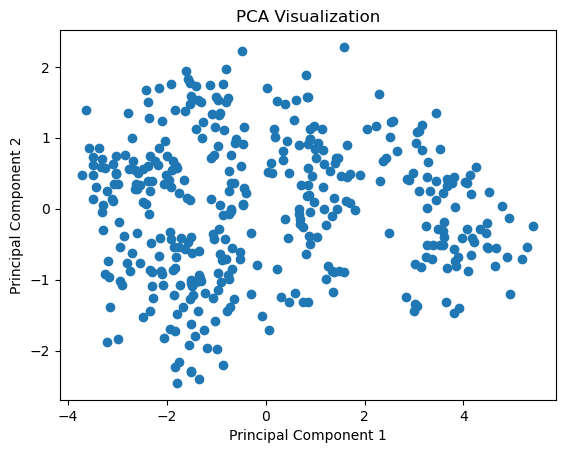

In [18]:
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()